# PEDIC FEEMS dataset demo

This notebook demonstrates:
- Loading the PEDIC FEEMS-style files
- Building pseudo-sites and sampling a GeoTIFF
- Training the multi-species resistance model
- Visualizing learned edge resistances


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import contextily as cx
import numpy as np
import torch

ROOT = os.path.dirname(os.path.dirname(os.getcwd())) if os.getcwd().endswith('notebooks') else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))

from multispecies_resistance.climate import download_climate_layers
from multispecies_resistance.io import list_pedic_species, load_pedic_species
from multispecies_resistance.train import build_species_graphs, train_model
from multispecies_resistance.viz import plot_multi_edge_resistance, plot_shared_resistance

torch.set_default_dtype(torch.float64)


In [2]:
PEDIC_DIR = '/Users/isaac/src/meems/pedic_feems_files'
species_names = list_pedic_species(PEDIC_DIR)
species_names[:5]


['anas', 'brevi', 'crano', 'densis', 'integ']

In [3]:
# Download and cache BioClim layers (used below by build_species_graphs)
raster_paths = download_climate_layers(
    source='bioclim',
    variables=['bio1', 'bio12'],
    resolution='2.5m',
    cache_dir='~/.cache/multispecies_resistance/climate',
)
len(raster_paths), raster_paths[:2]


(19,
 [PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_1.tif'),
  PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_2.tif')])

In [4]:
# Load a subset of species (sample-level only)
species_list = load_pedic_species(
    PEDIC_DIR,
    species_names=species_names,
    mmap_mode='r',
)
[s.name for s in species_list]


['anas',
 'brevi',
 'crano',
 'densis',
 'integ',
 'kansu',
 'lachno',
 'longi',
 'rhinanth',
 'szet',
 'tenu',
 'vert']

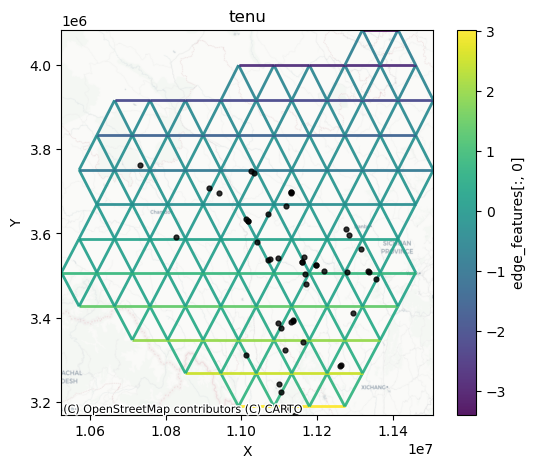

In [5]:
# Build graphs and train
graphs, stats = build_species_graphs(
    species_list,
    project_to='EPSG:3857',
    mesh_grid_type='triangular',
    bbox='convex_hull',
    #bbox_file="../../pedic_grid/hengduan_outer_latlong.txt",
    mesh_spacing_km=80,
    buffer_km=50.0,
    coord_order='latlon',
    coords_crs='EPSG:4326',
    raster_paths=raster_paths,
    raster_fill_method='nearest',
    standardize=True,
)

spidx = -2
ax, gdf = graphs[spidx].plot(edge_feature_idx=0, basemap=True)

In [9]:
model = train_model(graphs, hidden_dim=32, lr=1e-2, epochs=500, log_every=25, edge_smoothing=0.75)

epoch   25 loss 0.344277 val 0.029475
epoch   50 loss 0.264155 val 0.023126
epoch   75 loss 0.229970 val 0.020136
epoch  100 loss 0.213807 val 0.018715
epoch  125 loss 0.205802 val 0.018005
epoch  150 loss 0.201616 val 0.017630
epoch  175 loss 0.199320 val 0.017423
epoch  200 loss 0.198012 val 0.017303
epoch  225 loss 0.197245 val 0.017232
early stop at epoch 249 val 0.017191 best 0.017246


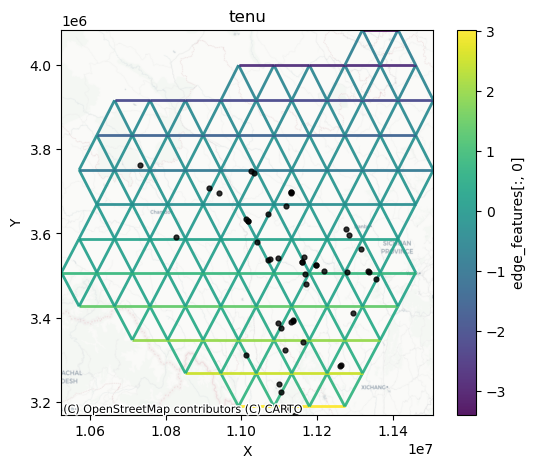

In [10]:
# Visualize edge-feature map for the selected species graph
spidx = -2
ax, gdf = graphs[spidx].plot(
    edge_feature_idx=0,
    basemap=True,
    title=species_list[spidx].name,
)


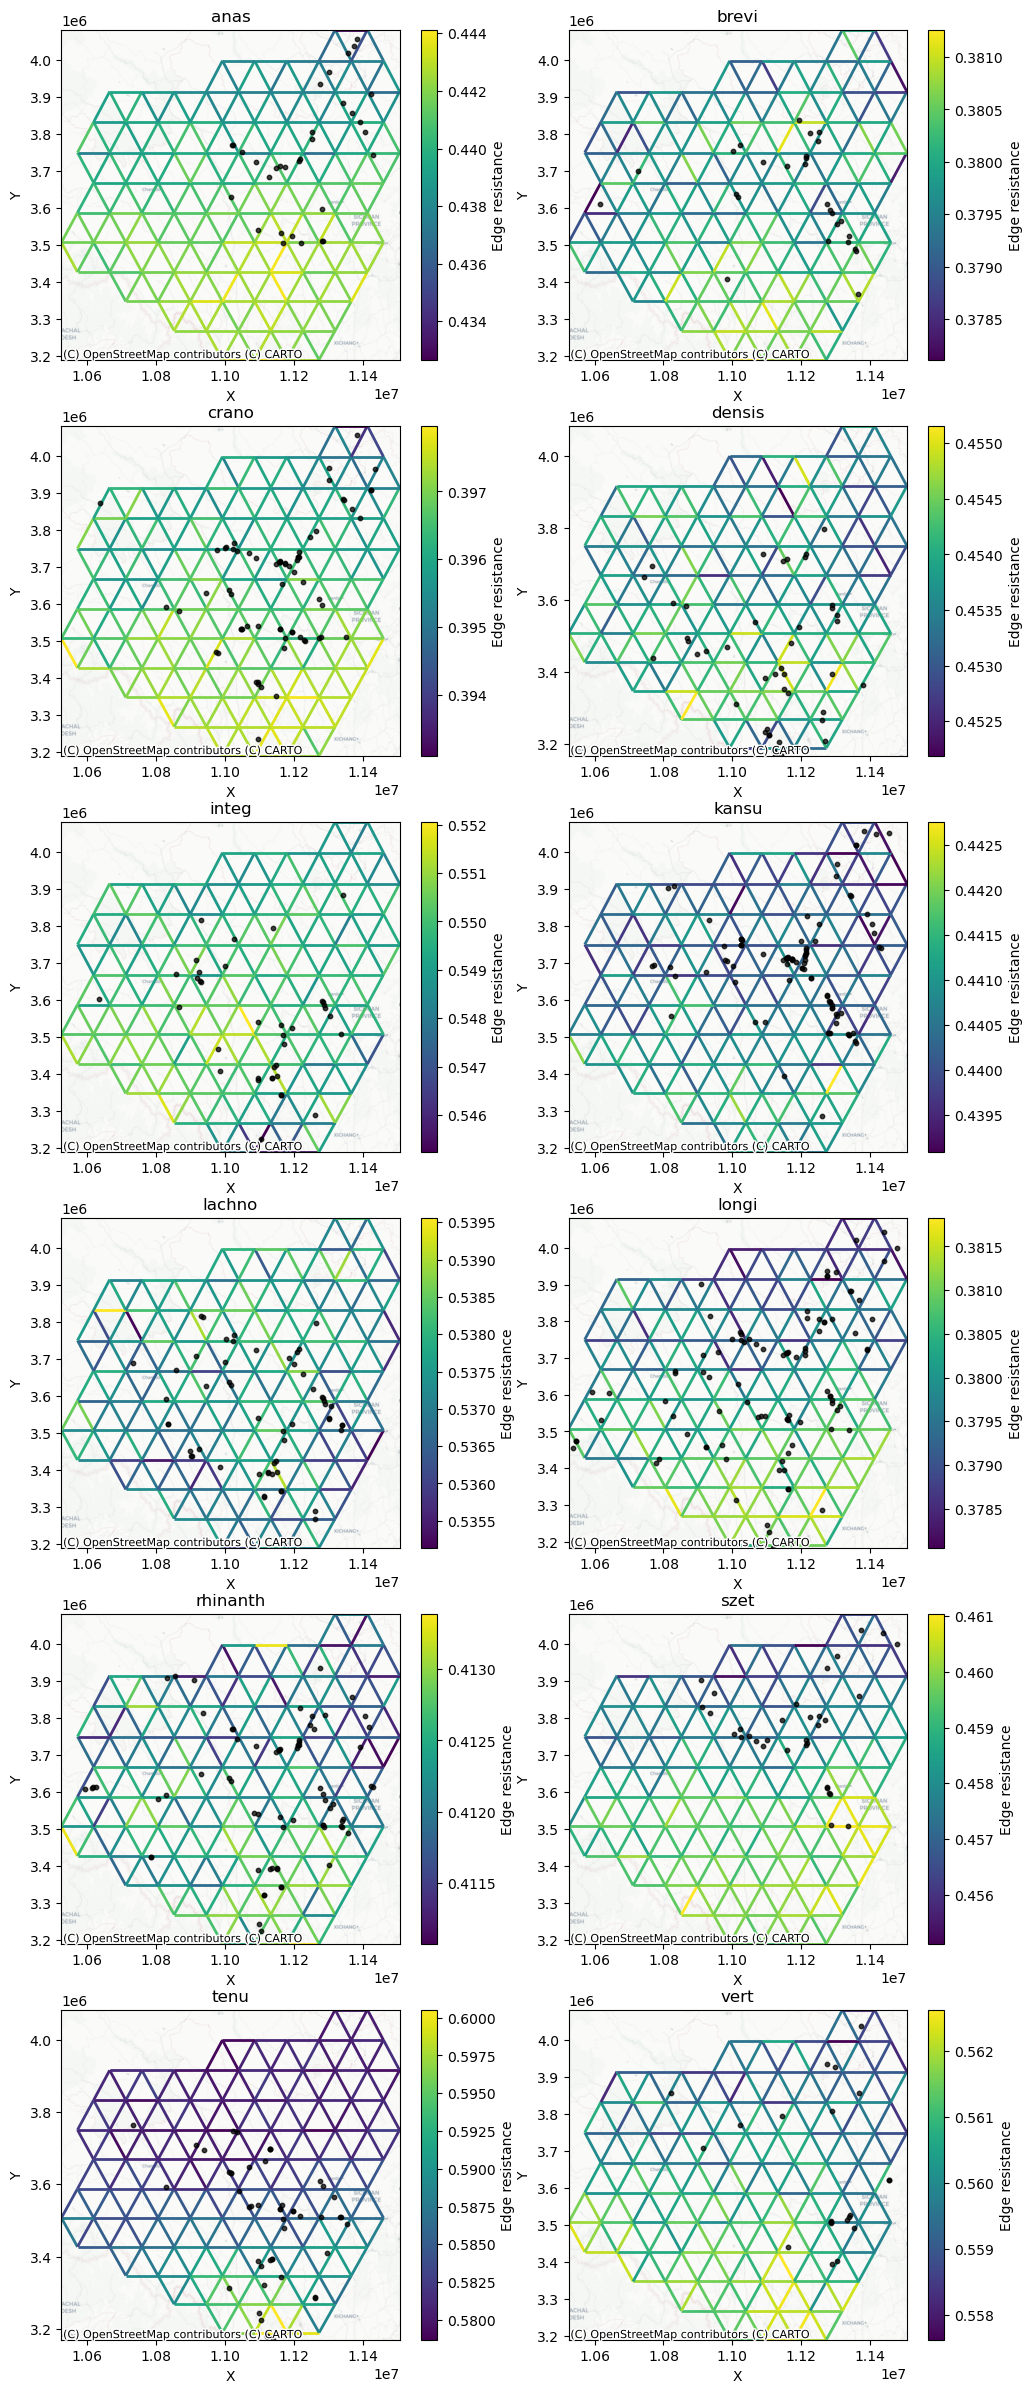

In [11]:
# Multi-species edge resistances (subplot grid)
_ = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    basemap=True,
    show_sites=True,
    explore=True,
    cmap="viridis",
)


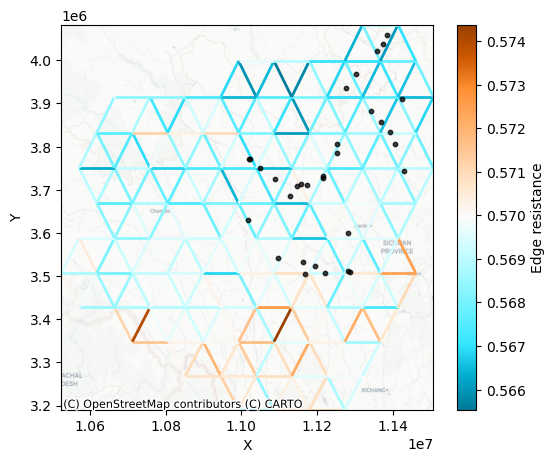

In [12]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    #graph_index=1,
    rasterize=False,
    interpolation='kriging',
    grid_size=200,
    explore=True,
    show_sites=True,
)
fig[2]

In [ ]:

# Optional: interactive explore map (all species overlay)
ax, gdf, fmap = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    overlay=True,
    explore=True,
    #cmap=None,
)
fmap


In [ ]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    #graph_index=1,
    rasterize=True,
    #interpolation='kriging',
    grid_size=200,
    #explore=True,
    #show_sites=True,
)


In [ ]:
graphs